<H2>MERGING THE DATASETS</H2>
For our project, we will be merging two datasets, where:</br>
<li> Dataset1 contains census information such as literacy rate, urban population, rural population, unemployment, dominant religions, and 
</li>
<li> Dataset2 contains statistics of various crimes against women over the time span 2001-2020</li> </br>

In [31]:
import pandas as pd
import re
df = pd.read_csv('Final-censusdataset-India.csv')  
print(df.head(3))


    state                                       District  persons     Male  \
0  Andhra    District Adilabad (01), Andhra Pradesh (28)  2488003  1250958   
1  Andhra   District Nizamabad (02), Andhra Pradesh (28)  2345685  1162905   
2  Andhra  District Karimnagar (03), Andhra Pradesh (28)  3491822  1747968   

    Female    rural  Person lit_rate  Male lit_Rate  Female lit_Rate  \
0  1237045  1827986            52.68          64.98            40.30   
1  1182780  1920947            52.02          64.91            39.48   
2  1743854  2813010            54.90          67.09            42.75   

   Tempworkers  ...  religion1 population  Religion2  Religion2 Population  \
0      1423248  ...               2207843        NaN                236844   
1      1159606  ...               1983275  2.Muslims                338824   
2      1711559  ...               3251834  2.Muslims                213811   

      Religion3  religion3 Population inhabitadevillages  drinkingwater  \
0         

In [32]:
df.columns

Index(['state', 'District', 'persons', 'Male', 'Female', 'rural',
       'Person lit_rate', 'Male lit_Rate', 'Female lit_Rate', 'Tempworkers',
       'Mainworkers', 'Marginal workers', 'Nonworkers', 'Religion1',
       'religion1 population', 'Religion2', 'Religion2 Population',
       'Religion3', 'religion3 Population', 'inhabitadevillages',
       'drinkingwater', 'electricity', 'primary school', 'Medical facility'],
      dtype='object')

In [33]:
def clean_district_name(district_name):
    cleaned_name = district_name.replace("District ", "")
    cleaned_name = re.sub(r"\(\d+\), .* \(\d+\)", "", cleaned_name).strip()  
    return cleaned_name

df['District'] = df['District'].apply(clean_district_name)
df.to_csv('cleaned_district_name.csv', index=False)

In [34]:
df1 = pd.read_csv('cleaned_district_name.csv')  
print(df.head(3))

    state    District  persons     Male   Female    rural  Person lit_rate  \
0  Andhra    Adilabad  2488003  1250958  1237045  1827986            52.68   
1  Andhra   Nizamabad  2345685  1162905  1182780  1920947            52.02   
2  Andhra  Karimnagar  3491822  1747968  1743854  2813010            54.90   

   Male lit_Rate  Female lit_Rate  Tempworkers  ...  religion1 population  \
0          64.98            40.30      1423248  ...               2207843   
1          64.91            39.48      1159606  ...               1983275   
2          67.09            42.75      1711559  ...               3251834   

   Religion2  Religion2 Population     Religion3  religion3 Population  \
0        NaN                236844           NaN                 24392   
1  2.Muslims                338824  3.Christians                 16204   
2  2.Muslims                213811  3.Christians                 20576   

  inhabitadevillages  drinkingwater electricity  primary school  \
0             

In [35]:
df2 = pd.read_csv('women-crimedataset-India (2).csv')  
print(df2.head(3))


            state   District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0  ANDHRA PRADESH   ADILABAD  2001.0    101                60   50   
1  ANDHRA PRADESH  ANANTAPUR  2001.0    151               125   23   
2  ANDHRA PRADESH   CHITTOOR  2001.0    101                57   27   

  CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0              0         50                     46   
1              0         23                     53   
2              0         27                     59   

  KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  \
0                                          30   
1                                          30   
2                                          34   

  KIDNAPPING AND ABDUCTION OF OTHERS DOWRY DEATHS  \
0                                 16           16   
1                                 23            7   
2                                 25           14   

  ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY  \
0                                  

In [36]:
df2.columns

Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'],
      dtype='object')

In [37]:
df1['District'] = df1['District'].str.strip().str.lower()
df2['District'] = df2['District'].str.strip().str.lower()

In [38]:
state_replacements = {
    'andhra': 'ANDHRA PRADESH',
    'd & n haweli': 'D & N HAVELI',
    'delhi': 'DELHI UT',
    'hp': 'HIMACHAL PRADESH',
    'jk': 'JAMMU & KASHMIR',
    'tn': 'TAMIL NADU',
    'up': 'UTTAR PRADESH'
}

df1['state'] = df1['state'].replace(state_replacements)
df2['state'] = df2['state'].replace(state_replacements)

In [39]:
merged_df = pd.merge(df2, df1, left_on='District', right_on='District', how='inner')


In [40]:
merged_df.head()

,state_x,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion1 population,Religion2,Religion2 Population,Religion3,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility
0,ANDHRA PRADESH,adilabad,2001.0,101,60,50,0,50,46,30,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
1,ANDHRA PRADESH,adilabad,2002.0,100,79,37,0,37,42,32,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
2,ANDHRA PRADESH,adilabad,2003.0,107,65,35,0,35,46,16,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
3,ANDHRA PRADESH,adilabad,2004.0,113,83,50,0,50,48,42,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
4,ANDHRA PRADESH,adilabad,2005.0,108,48,53,0,53,65,46,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976


In [41]:
merged_df.to_csv('merged_dataset.csv', index=False)


<H2>DATA PREPROCESSING:</H2>
<p>Since we have two columns containing State name values, we will drop one of the columns</p>

In [42]:
merged_df.rename(columns={'state_x': 'state'}, inplace=True)
merged_df.drop(columns=['state_y'], inplace=True)

print(merged_df.head(3))
merged_df.to_csv('merged_dataset.csv', index=False)

            state  District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0  ANDHRA PRADESH  adilabad  2001.0    101                60   50   
1  ANDHRA PRADESH  adilabad  2002.0    100                79   37   
2  ANDHRA PRADESH  adilabad  2003.0    107                65   35   

  CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0              0         50                     46   
1              0         37                     42   
2              0         35                     46   

  KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ... religion1 population  \
0                                          30  ...              2207843   
1                                          32  ...              2207843   
2                                          16  ...              2207843   

  Religion2 Religion2 Population Religion3 religion3 Population  \
0       NaN               236844       NaN                24392   
1       NaN               236844       NaN                24392   
2   

<H3> REARRANGING THE MERGED DATASET IN ASCENDING ORDER (IN ORDER OF 'state', 'District', 'YEAR' columns) and RESETTING THE INDEX</H3>


In [43]:
merged_df = merged_df.sort_values(by=['state', 'District', 'YEAR'])
merged_df = merged_df.reset_index(drop=True)
merged_df.head()

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,religion1 population,Religion2,Religion2 Population,Religion3,religion3 Population,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility
0,ANDHRA PRADESH,adilabad,2001.0,101,60,50,0,50,46,30,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
1,ANDHRA PRADESH,adilabad,2002.0,100,79,37,0,37,42,32,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
2,ANDHRA PRADESH,adilabad,2003.0,107,65,35,0,35,46,16,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
3,ANDHRA PRADESH,adilabad,2004.0,113,83,50,0,50,48,42,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976
4,ANDHRA PRADESH,adilabad,2005.0,108,48,53,0,53,65,46,...,2207843,NaN,236844,NaN,24392,1586.0,1585.0,1585.0,1521.0,976


<H3> STANDARDIZING ALL THE STATE NAMES</H3>


In [44]:
def standardize_state_name(state_name):
    state_mapping = {
        'CHHATISGARH': 'CHHATTISGARH',
        'CHHATTISGARH': 'CHHATTISGARH',
        'CHATTISGARH': 'CHHATTISGARH',
        'TAMILNADU': 'TAMIL NADU',
        'TAMIL NADU': 'TAMIL NADU',
        'Chandigarh': 'CHANDIGARH',
        'CHANDIGARH': 'CHANDIGARH',
        'DELHI': 'DELHI UT',
        'DELHI UT': 'DELHI UT',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYA PRADESH': 'MADHYA PRADESH',
        'MADHYAPRADESH': 'MADHYA PRADESH',
        'Lakshadweep': 'LAKSHADWEEP',
        'LAKSHADWEEP': 'LAKSHADWEEP',
        'ANDHRA PRADESH ': 'ANDHRA PRADESH',
        'ANDHRA PRADESH': 'ANDHRA PRADESH',
        
    }
    return state_mapping.get(state_name, state_name)

merged_df['state'] = merged_df['state'].apply(standardize_state_name)

merged_df['state'].unique()

array(['ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', 'BIHAR',
       'CHANDIGARH', 'CHHATTISGARH', 'DELHI UT', 'GOA', 'GUJARAT',
       'HARYANA', 'HIMACHAL PRADESH', 'JHARKHAND', 'KARNATAKA', 'KERALA',
       'MADHYA PRADESH', 'MADHYA PRADESH  ', 'MAHARASHTRA', 'MANIPUR',
       'MEGHALAYA', 'MIZORAM', 'NAGALAND', 'ODISHA', 'PUNJAB',
       'RAJASTHAN', 'SIKKIM', 'TAMIL NADU', 'TELANGANA', 'TRIPURA',
       'UTTAR PRADESH', 'UTTARAKHAND', 'WEST BENGAL'], dtype=object)

In [45]:
merged_df['Religion1'] = merged_df['Religion1'].str.split('.').str[1].str.strip()
merged_df['Religion2'] = merged_df['Religion2'].str.split('.').str[1].str.strip()
merged_df['Religion3'] = merged_df['Religion3'].str.split('.').str[1].str.strip()

print(merged_df)
merged_df.to_csv('merged_dataset.csv', index=False)


               state        District    YEAR MURDER ATTEMPT TO MURDER RAPE  \
0     ANDHRA PRADESH        adilabad  2001.0    101                60   50   
1     ANDHRA PRADESH        adilabad  2002.0    100                79   37   
2     ANDHRA PRADESH        adilabad  2003.0    107                65   35   
3     ANDHRA PRADESH        adilabad  2004.0    113                83   50   
4     ANDHRA PRADESH        adilabad  2005.0    108                48   53   
...              ...             ...     ...    ...               ...  ...   
6479     WEST BENGAL  uttar dinajpur  2010.0     63               106  130   
6480     WEST BENGAL  uttar dinajpur  2011.0     66               178  126   
6481     WEST BENGAL  uttar dinajpur  2012.0    110               283   92   
6482     WEST BENGAL  uttar dinajpur  2015.0    NaN                86   50   
6483     WEST BENGAL  uttar dinajpur  2019.0      0                39   42   

     CUSTODIAL RAPE OTHER RAPE KIDNAPPING & ABDUCTION  \
0     

In [46]:
print(merged_df.columns)


Index(['state', 'District', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER', 'RAPE',
       'CUSTODIAL RAPE', 'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'persons', 'Male',
       'Female', 'rural', 'Person lit_rate', 'Male lit_Rate',
       'Female lit_Rate', 'Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'Religion1', 'religion1 population', 'Religion2',
       'Religion2 Population', 'Religion3', 'religion3 Population',
       'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school',
       'Medical facility'],
      dtype='object')


For the purpose of this study, while analysing crime patterns against women in India, we will look at the recent census parameters: such as literacy rate (overall, male literacy, female literacy
'Total Population'
'Male Population',
'Female Population', 
'rural', 
'urban', 
'Personlit_rate',
'Mlit_Rate', 
'Flit_Rate', 
'Totalworkers',
'Mainworkers', 
'Marginal workers', 
'Nonworkers', 
'Religion1',
'religion1 population', 'Religion2', 'Religion2 Population',



and other irrelevant columns for the purpose of this study ie 'inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility', we will drop from the dataset
       

<H2> DERIVED COLUMNS:</H2>

In [47]:
# Calculating unemployment rate
merged_df['unemployment_rate'] = (merged_df['Nonworkers'] / (merged_df['Tempworkers'] + merged_df['Mainworkers'] + merged_df['Marginal workers'])) * 100

# Calculating urban population
merged_df['persons'] = pd.to_numeric(merged_df['persons'], errors='coerce')
merged_df['rural'] = pd.to_numeric(merged_df['rural'], errors='coerce')
merged_df['urban_population'] = merged_df['persons'] - merged_df['rural']





In [48]:
#converting string values to numeric

columns_to_convert = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
    'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

for column in columns_to_convert:
    merged_df[column] = pd.to_numeric(merged_df[column], errors='coerce')

In [49]:
#Creating column of total number of offences

all_crimes = ['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                  'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                  'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                  'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                  'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                  'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES']

merged_df['total'] = merged_df[all_crimes].sum(axis=1)


In [50]:
#Creating column of total number of cognizable offences
"""As per CRPC Schedule I, the following are considered Cognizable offences
'MURDER', 'ATTEMPT TO MURDER', 'RAPE', ' CUSTODIAL RAPE', 'OTHER RAPE','KIDNAPPING & ABDUCTION', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS','KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

cognizable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
    'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
    'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'INSULT TO MODESTY OF WOMEN',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Cognizable Offences'] = merged_df[cognizable_offences].sum(axis=1)



In [51]:
#Creating column of total number of Non-Bailable offences
"""As per CRPC Schedule I, the following are considered Non-Bailable offences
'MURDER', 'ATTEMPT TO MURDER', RAPE',' CUSTODIAL RAPE', 'OTHER RAPE', 
'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS', 
'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 
'CRUELTY BY HUSBAND OR HIS RELATIVES','IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'

""" 

non_bailable_offences = [
    'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
    'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'KIDNAPPING AND ABDUCTION OF OTHERS',
    'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
    'CRUELTY BY HUSBAND OR HIS RELATIVES', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'
]

merged_df['Total Non-Bailable Offences'] = merged_df[non_bailable_offences].sum(axis=1)


<H2> RENAMING CERTAIN COLUMNS:</H2>

In [52]:
merged_df.rename(columns={'rural': 'rural_population'}, inplace=True)

merged_df.rename(columns={'Religion1': 'First Dominant Religion'}, inplace=True)

merged_df.rename(columns={'Religion2': 'Second Dominant Religion'}, inplace=True)

merged_df.rename(columns={'persons': 'Total Population'}, inplace=True)

merged_df.rename(columns={'Male': 'Male Population'}, inplace=True)

merged_df.rename(columns={'Female': 'Female Population'}, inplace=True)

merged_df.rename(columns={'Person lit_rate': 'Total Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Male lit_Rate': 'Male Literacy Rate'}, inplace=True)

merged_df.rename(columns={'Female lit_Rate': 'Female Literacy Rate'}, inplace=True)



<H2> REMOVING ANY DUPLICATE ROWS</H2>
<H4> removing duplicates where the state, District, and YEAR values are the same</H4>

In [53]:
merged_df = merged_df.drop_duplicates(subset=['state', 'District', 'YEAR'], keep='last')

merged_df

,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,inhabitadevillages,drinkingwater,electricity,primary school,Medical facility,unemployment_rate,urban_population,total,Total Cognizable Offences,Total Non-Bailable Offences
0,ANDHRA PRADESH,adilabad,2001.0,101.0,60,50,0.0,50.0,46,30,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,727.0,727.0,647.0
1,ANDHRA PRADESH,adilabad,2002.0,100.0,79,37,0.0,37.0,42,32,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,834.0,834.0,729.0
2,ANDHRA PRADESH,adilabad,2003.0,107.0,65,35,0.0,35.0,46,16,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,763.0,763.0,678.0
3,ANDHRA PRADESH,adilabad,2004.0,113.0,83,50,0.0,50.0,48,42,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,908.0,908.0,789.0
4,ANDHRA PRADESH,adilabad,2005.0,108.0,48,53,0.0,53.0,65,46,...,1586.0,1585.0,1585.0,1521.0,976,53.593448,660017.0,914.0,914.0,772.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6479,WEST BENGAL,uttar dinajpur,2010.0,63.0,106,130,0.0,130.0,118,99,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1259.0,1259.0,1140.0
6480,WEST BENGAL,uttar dinajpur,2011.0,66.0,178,126,0.0,126.0,172,149,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1418.0,1418.0,1245.0
6481,WEST BENGAL,uttar dinajpur,2012.0,110.0,283,92,0.0,92.0,306,258,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,1976.0,1976.0,1665.0
6482,WEST BENGAL,uttar dinajpur,2015.0,NaN,86,50,0.0,NaN,1,72,...,1477.0,1465.0,757.0,1044.0,648,80.504081,294443.0,844.0,844.0,838.0


<h2>DROPPING IRRELEVANT COLUMNS:</h2>

In [54]:
# Dropping irrelevant columns
irrelevant_columns = ['inhabitadevillages', 'drinkingwater', 'electricity', 'primary school', 'Medical facility']
merged_df = merged_df.drop(columns=irrelevant_columns)

#Dropping columns that we don't need anymore
irrelevant_columns = ['Tempworkers', 'Mainworkers', 'Marginal workers',
       'Nonworkers', 'religion1 population', 
       'Religion2 Population', 'Religion3', 'religion3 Population']
merged_df = merged_df.drop(columns=irrelevant_columns)

print(merged_df.head(3))

            state  District    YEAR  MURDER  ATTEMPT TO MURDER  RAPE  \
0  ANDHRA PRADESH  adilabad  2001.0   101.0                 60    50   
1  ANDHRA PRADESH  adilabad  2002.0   100.0                 79    37   
2  ANDHRA PRADESH  adilabad  2003.0   107.0                 65    35   

   CUSTODIAL RAPE  OTHER RAPE  KIDNAPPING & ABDUCTION  \
0             0.0        50.0                      46   
1             0.0        37.0                      42   
2             0.0        35.0                      46   

   KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS  ...  Total Literacy Rate  \
0                                           30  ...                52.68   
1                                           32  ...                52.68   
2                                           16  ...                52.68   

   Male Literacy Rate  Female Literacy Rate  First Dominant Religion  \
0               64.98                  40.3                      NaN   
1               64.98            

<h2>FEATURE SELECTION</h2>

In [56]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Assuming merged_df contains your dataset
X = merged_df.drop(columns=["state", "District", "YEAR", "First Dominant Religion", "Second Dominant Religion"])  
y = merged_df["total"]

# Store column names
column_names = X.columns

# Impute missing values
imputer = SimpleImputer(strategy='mean')  
X_imputed = imputer.fit_transform(X)

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Apply feature selection
k_best = 5  # Choose the number of top features to select
selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
selector.fit(X_scaled, y)

# Get selected features
selected_features_filter = column_names[selector.get_support()]

print("Filter Method (SelectKBest) Selected Features:", selected_features_filter)


Filter Method (SelectKBest) Selected Features: Index(['CUSTODIAL RAPE', 'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'total', 'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


In [74]:
#Embedded Method
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Create Lasso Regression model
lasso_model = Lasso(alpha=0.04)  

# Fit the model
lasso_model.fit(X_scaled, y)

# Get selected features (non-zero coefficients)
selected_features_embedded = X.columns[lasso_model.coef_ != 0]

print("Embedded Method (Lasso Regression) Selected Features:", selected_features_embedded)


Embedded Method (Lasso Regression) Selected Features: Index(['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
       'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
       'Male Literacy Rate', 'urban_population', 'total',
       'Total Cognizable Offences', 'Total Non-Bailable Offences'],
      dtype='object')


In [27]:
import pandas as pd
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Create Logistic Regression model
logistic_regression = LogisticRegression()

# Initialize RFE with Logistic Regression as the estimator
rfe = RFE(estimator=logistic_regression, n_features_to_select=5)  # You can adjust the number of features to select

# Fit RFE
rfe.fit(X_scaled, y)

# Get selected features
selected_features_wrapper = X.columns[rfe.support_]

print("Wrapper Method (RFE) Selected Features:", selected_features_wrapper)


/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modul

Wrapper Method (RFE) Selected Features: Index(['RAPE', 'rural_population', 'total', 'Total Cognizable Offences',
       'Total Non-Bailable Offences'],
      dtype='object')


/Users/rudranighosh/anaconda/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


<h2>HEATMAP</h2>

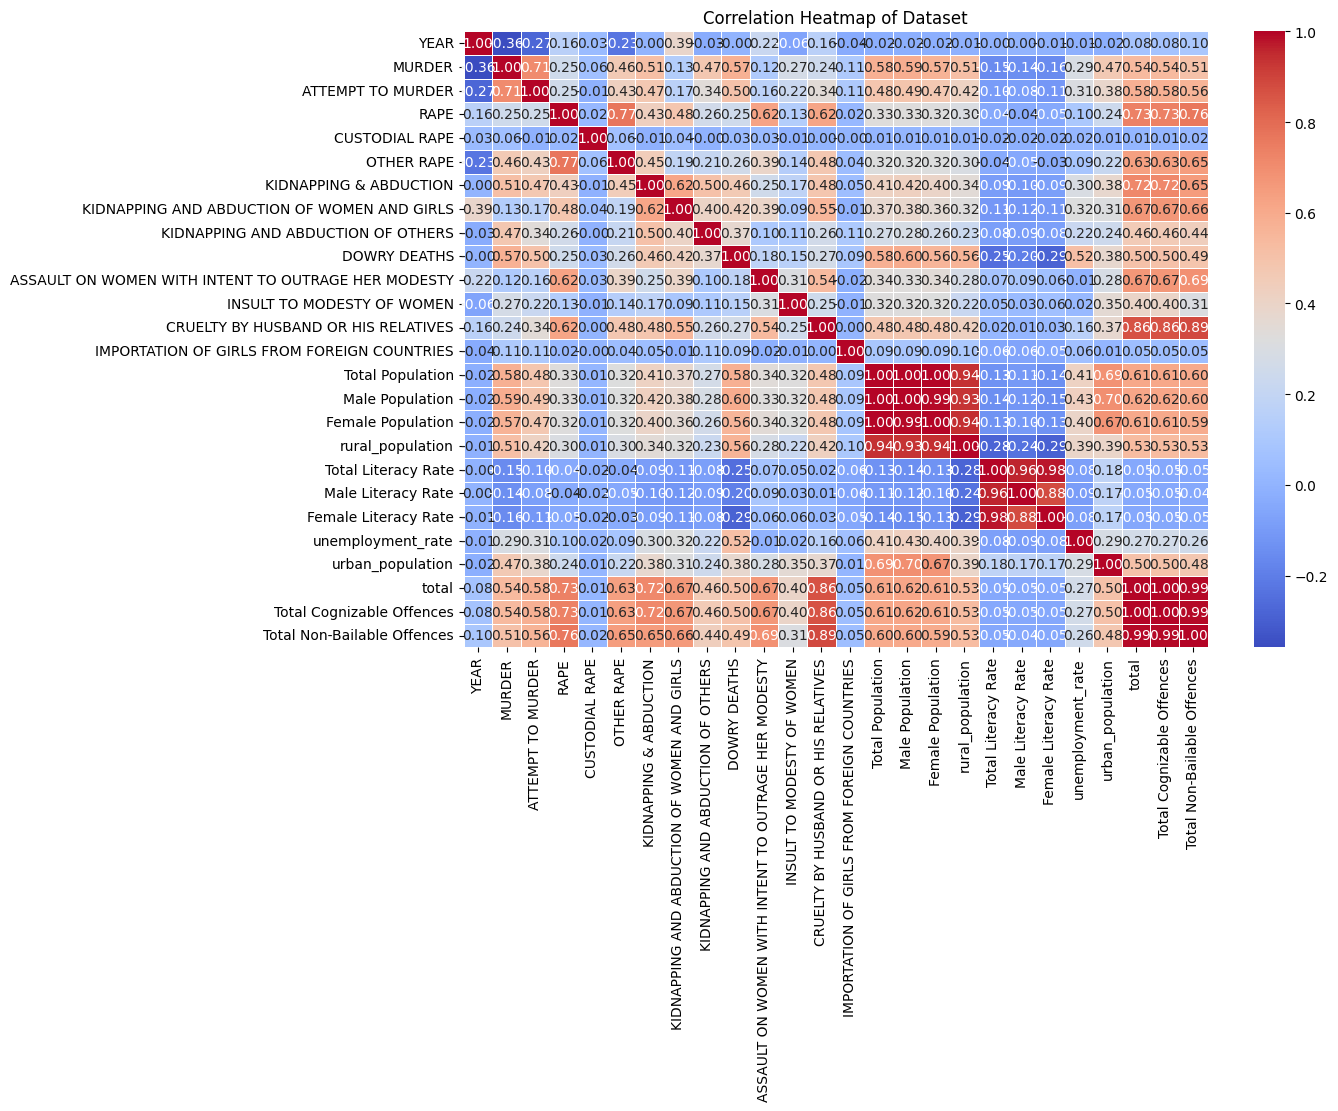

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = merged_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Dataset')
plt.show()


In [67]:
import pandas as pd
import numpy as np

# Assuming merged_df contains your dataset
# Select only numeric columns
numeric_df = merged_df.select_dtypes(include=['number'])

# Fill missing values with the mean of each column
numeric_df = numeric_df.fillna(numeric_df.mean())

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Find the top correlated columns
# Create a mask to exclude self-correlation and duplicate entries
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
correlation_matrix = correlation_matrix.mask(mask)

# Get the top correlated column pairs/triples
# Iterate through each column and find the column with the highest correlation
top_correlated_pairs = []
top_correlated_triples = []
for col in correlation_matrix.columns:
    # Get the column with the highest correlation (excluding itself)
    top_correlated_col = correlation_matrix[col].idxmax()
    max_corr = correlation_matrix[col].max()
    top_correlated_pairs.append((col, top_correlated_col, max_corr))
    
    # Find the top correlated triples
    for other_col in correlation_matrix.columns:
        if other_col != col and other_col != top_correlated_col:
            try:
                corr1 = correlation_matrix[col][other_col]
                corr2 = correlation_matrix[top_correlated_col][other_col]
                if np.isnan(corr1) or np.isnan(corr2):  # Check for NaN values
                    continue
                avg_corr = (corr1 + corr2) / 2
                top_correlated_triples.append((col, top_correlated_col, other_col, avg_corr))
            except KeyError:
                continue

# Sort the top correlated pairs and triples by correlation value
top_correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
top_correlated_triples.sort(key=lambda x: abs(x[3]), reverse=True)

# Extract top 5 correlated pairs and triples
top_5_correlated_pairs = top_correlated_pairs[:5]
top_5_correlated_triples = top_correlated_triples[:5]

print("Top 5 correlated column pairs:")
for pair in top_5_correlated_pairs:
    print(pair)

print("\nTop 5 correlated column triples:")
for triple in top_5_correlated_triples:
    print(triple)


Top 5 correlated column pairs:
('total', 'Total Cognizable Offences', 1.0)
('Total Population', 'Male Population', 0.9986128830799519)
('Male Population', 'Female Population', 0.994064733981623)
('Total Cognizable Offences', 'Total Non-Bailable Offences', 0.9899221675673969)
('Total Literacy Rate', 'Female Literacy Rate', 0.9765442703320122)

Top 5 correlated column triples:
('Total Population', 'Male Population', 'Female Population', 0.9962393420121396)
('total', 'Total Cognizable Offences', 'Total Non-Bailable Offences', 0.9899221675673969)
('Male Population', 'Female Population', 'rural_population', 0.9178086382676932)
('Total Population', 'Male Population', 'rural_population', 0.9148807848258171)
('KIDNAPPING & ABDUCTION', 'total', 'Total Cognizable Offences', 0.8592249564454444)


<h2>DIMENSIONALITY REDUCTION</h2>

<OL><LI> DROPPING CORRELATED COLUMNS:</LI>
<LI> FORWARD SELECTION:</LI>
<LI> BACKWARD ELIMINATION:</LI></OL>


<H2>PLOTS</H2>

In [79]:
final_df=merged_df[["state", "District", "YEAR",'MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
       'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
       'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
       'Male Literacy Rate', 'urban_population', 'total',
       'Total Cognizable Offences', 'Total Non-Bailable Offences']]

final_df.fillna(0, inplace=True)
final_df.to_csv('final_dataset.csv', index=False)
final_df.head(5)


/var/folders/xn/1_g50z0x7z1cl56zcnwgl2sh0000gn/T/ipykernel_70024/1457231153.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  final_df.fillna(0, inplace=True)


,state,District,YEAR,MURDER,ATTEMPT TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS,...,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,Male Population,Male Literacy Rate,urban_population,total,Total Cognizable Offences,Total Non-Bailable Offences
0,ANDHRA PRADESH,adilabad,2001.0,101.0,60,50,0.0,50.0,46,30,...,149,34,175,0,1250958,64.98,660017.0,727.0,727.0,647.0
1,ANDHRA PRADESH,adilabad,2002.0,100.0,79,37,0.0,37.0,42,32,...,174,63,240,0,1250958,64.98,660017.0,834.0,834.0,729.0
2,ANDHRA PRADESH,adilabad,2003.0,107.0,65,35,0.0,35.0,46,16,...,141,39,238,0,1250958,64.98,660017.0,763.0,763.0,678.0
3,ANDHRA PRADESH,adilabad,2004.0,113.0,83,50,0.0,50.0,48,42,...,135,71,296,0,1250958,64.98,660017.0,908.0,908.0,789.0
4,ANDHRA PRADESH,adilabad,2005.0,108.0,48,53,0.0,53.0,65,46,...,144,77,280,0,1250958,64.98,660017.0,914.0,914.0,772.0


<H2>BOXPLOT</H2>

In [89]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_boxplot(state, district, year_range, column):
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].isin(year_range))]
    
    plt.figure(figsize=(10, 6))
    filtered_df.boxplot(column=column)
    plt.title(f'Boxplot for {column} in {state}, {district} - Year {min(year_range)} to {max(year_range)}')
    plt.ylabel(column)
    plt.xticks(rotation=45)
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')
column_dropdown = widgets.Dropdown(options=['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                                            'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                                            'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                                            'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                                            'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                                            'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES', 'Male Population',
                                            'Male Literacy Rate', 'urban_population', 'total',
                                            'Total Cognizable Offences', 'Total Non-Bailable Offences'], 
                                   description='Column:')

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_boxplot, state=state_dropdown, district=district_dropdown, year_range=year_range_slider, column=column_dropdown)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_boxplot(state, district, year_range, column)>

<h2>PIE CHART</h2>

In [92]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# Define function to create pie chart
def plot_crime_pie_chart(state, district, year_range):
    try:
        # Filter data based on selected state, district, and time range
        filtered_df = final_df[(final_df['state'] == state) & 
                               (final_df['District'] == district) & 
                               (final_df['YEAR'].between(year_range[0], year_range[1]))]

        # Calculate total number of each type of crime across all years
        total_crimes = filtered_df[['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                                     'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                                     'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                                     'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                                     'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                                     'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES']].sum()

        # Create pie chart
        plt.figure(figsize=(8, 8))
        plt.pie(total_crimes, labels=total_crimes.index, autopct='%1.1f%%', startangle=140)
        plt.title(f'Crime Distribution in {state}, {district} - Year Range: {year_range[0]}-{year_range[1]}')
        plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
        plt.show()
    except Exception as e:
        print("An error occurred:", e)

# Create dropdown widgets for state, district, and year range
state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')
district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')

# Define function to update district dropdown based on selected state
def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

# Link state dropdown with district dropdown
widgets.interactive(update_district_dropdown, state=state_dropdown)

# Use interact to link the dropdowns with the plotting function
interact(plot_crime_pie_chart, state=state_dropdown, district=district_dropdown, year_range=year_range_slider)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_crime_pie_chart(state, district, year_range)>

<h2>HISTOGRAM</h2>

In [93]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

def plot_crime_histogram(state, district, year_range, crime_type):
    filtered_df = final_df[(final_df['state'] == state) & 
                           (final_df['District'] == district) & 
                           (final_df['YEAR'].between(year_range[0], year_range[1]))]
    
    crime_data = filtered_df[crime_type]
    
    plt.figure(figsize=(10, 6))
    plt.hist(crime_data, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {crime_type} in {state}, {district} - Year Range: {year_range[0]}-{year_range[1]}')
    plt.xlabel(crime_type)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:')
district_dropdown = widgets.Dropdown(description='District:')
year_range_slider = widgets.IntRangeSlider(min=2001, max=2020, step=1, value=[2001, 2020], description='Year Range:')
crime_type_dropdown = widgets.Dropdown(options=['MURDER', 'ATTEMPT TO MURDER', 'RAPE', 'CUSTODIAL RAPE', 'OTHER RAPE',
                                                'KIDNAPPING & ABDUCTION', 'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
                                                'KIDNAPPING AND ABDUCTION OF OTHERS', 'DOWRY DEATHS',
                                                'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
                                                'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
                                                'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES'], description='Crime Type:')

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_histogram, state=state_dropdown, district=district_dropdown, year_range=year_range_slider, crime_type=crime_type_dropdown)


interactive(children=(Dropdown(description='State:', options=('ANDHRA PRADESH', 'ARUNACHAL PRADESH', 'ASSAM', …

<function __main__.plot_crime_histogram(state, district, year_range, crime_type)>

<h2>LINE PLOT</h2>

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Layout

state_dropdown = widgets.Dropdown(options=final_df['state'].unique(), description='State:', layout=Layout(width='300px'))
district_dropdown = widgets.Dropdown(description='District:', layout=Layout(width='300px'))

def update_district_dropdown(state):
    district_dropdown.options = final_df[final_df['state'] == state]['District'].unique()

def plot_crime_trend(state, district):
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    plt.figure(figsize=(15, 8))
    for crime_param in crime_parameters:
        sns.lineplot(x='YEAR', y=crime_param, data=filtered_data, label=crime_param)
    plt.title('Crime Trend Over Time')
    plt.xlabel('Year')
    plt.ylabel('Number of Crimes')
    plt.legend()
    plt.grid(True)
    plt.show()

widgets.interactive(update_district_dropdown, state=state_dropdown)

interact(plot_crime_trend, state=state_dropdown, district=district_dropdown)


interactive(children=(Dropdown(description='State:', layout=Layout(width='300px'), options=('ANDHRA PRADESH', …

<function __main__.plot_crime_trend(state, district)>

<H2>SCATTER PLOT</H2>

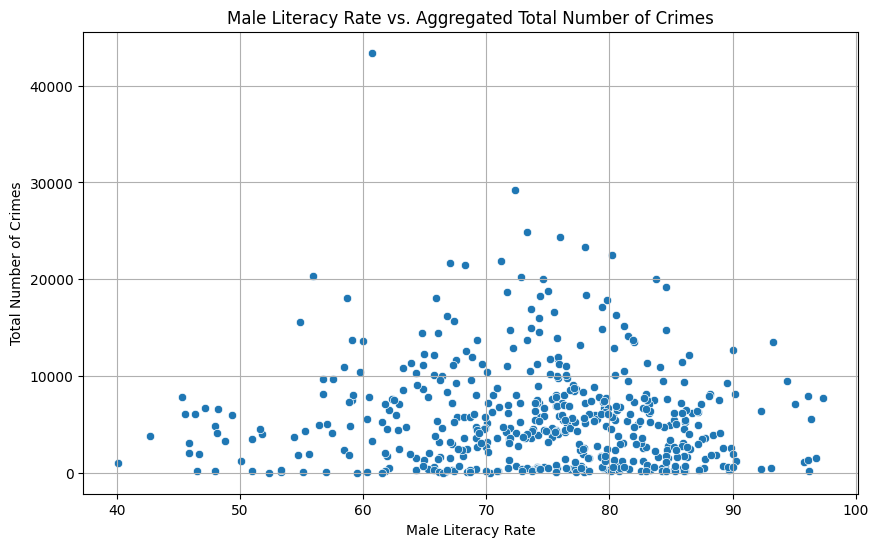

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create scatter plot
def plot_male_literacy_vs_aggregated_crimes(state=None, district=None):
    # Filter data based on selected state and district
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    # Aggregate total number of crimes over the years
    aggregated_crimes = filtered_data.groupby(['state', 'District', 'Male Literacy Rate'])['total'].sum().reset_index()
    
    # Create scatter plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Male Literacy Rate', y='total', data=aggregated_crimes)
    plt.title('Male Literacy Rate vs. Aggregated Total Number of Crimes')
    plt.xlabel('Male Literacy Rate')
    plt.ylabel('Total Number of Crimes')
    plt.grid(True)
    plt.show()

# Plot male literacy rate vs. aggregated total number of crimes
plot_male_literacy_vs_aggregated_crimes()


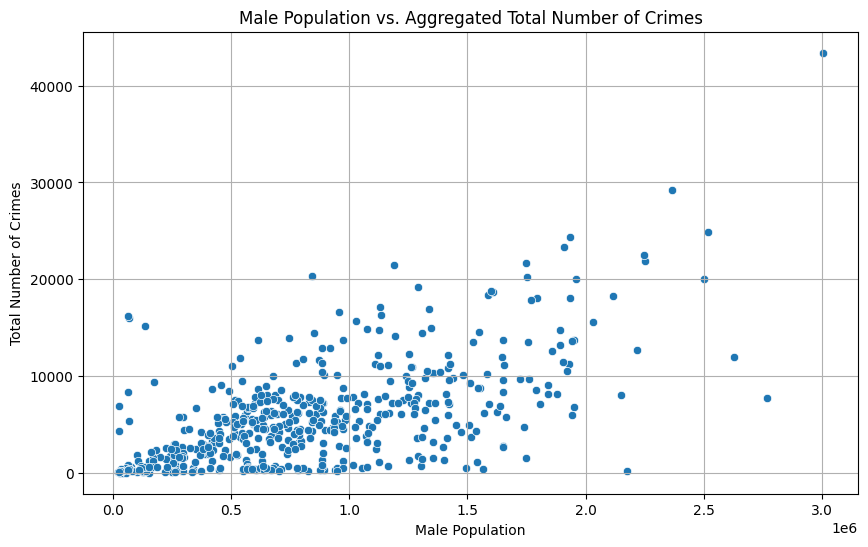

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Function to create scatter plot
def plot_male_popln_vs_aggregated_crimes(state=None, district=None):
    # Filter data based on selected state and district
    filtered_data = final_df.copy()
    if state:
        filtered_data = filtered_data[filtered_data['state'] == state]
    if district:
        filtered_data = filtered_data[filtered_data['District'] == district]
    
    # Aggregate total number of crimes over the years
    aggregated_crimes = filtered_data.groupby(['state', 'District', 'Male Population'])['total'].sum().reset_index()
    
    # Create scatter plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x='Male Population', y='total', data=aggregated_crimes)
    plt.title('Male Population vs. Aggregated Total Number of Crimes')
    plt.xlabel('Male Population')
    plt.ylabel('Total Number of Crimes')
    plt.grid(True)
    plt.show()

# Plot male literacy rate vs. aggregated total number of crimes
plot_male_popln_vs_aggregated_crimes()


<H2>FORECASTING CRIME TRENDS</H2>
